In [1]:
import numpy as np #handle large Multi-D arrays and matrices
import pandas as pd
import os
import cv2 #Open source computer vision library - It is used for image processing
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split #Splitting of Data into training and testing data
from sklearn.decomposition import PCA #Principal Component Analysis (determines best fit line) (dimensionality reduction)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
 #Dictionary 
classes = {'no_tumor': 0, 'pituitary_tumor':1,'glioma_tumor':2,'meningioma_tumor':3}

#Load and preprocess data 
X=[]
Y=[] #Lists

for cls,labels in classes.items():
    pth =f"C:\\Users\\Dell\\Documents\\IISC\\Training\\{cls}" #\\ to represent actual backslash character and not escape the sequence \
    for filename in os.listdir(pth):
        img = cv2.imread(os.path.join(pth,filename),0) # 0 means load into grayscale mode
        img = cv2.resize(img,(200,200))
        X.append(img.flatten()/255.0)
        Y.append(labels)
X=np.array(X)
Y=np.array(Y)


In [3]:
# Cell 3

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.2,
    stratify=Y
)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)

pca_test = pca.transform(xtest)

# -----------------------------
# RBF Kernel SVM
# -----------------------------

sv_rbf = SVC(kernel='rbf')

sv_rbf.fit(pca_train, ytrain)

rbf_pred = sv_rbf.predict(pca_test)

# -----------------------------
# Linear Kernel SVM
# -----------------------------

sv_linear = SVC(kernel='linear')

sv_linear.fit(pca_train, ytrain)

linear_pred = sv_linear.predict(pca_test)

# -----------------------------
# Evaluation Function
# -----------------------------

def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    cm = confusion_matrix(y_true, y_pred)

    sensitivity = np.mean(
        np.diag(cm) / np.sum(cm, axis=1)
    )

    specificity = []

    for i in range(len(cm)):

        tn = np.sum(cm) - (
            np.sum(cm[i,:]) +
            np.sum(cm[:,i]) -
            cm[i,i]
        )

        fp = np.sum(cm[:,i]) - cm[i,i]

        specificity.append(
            tn / (tn + fp)
        )

    specificity = np.mean(specificity)

    return accuracy, f1, sensitivity, specificity

# -----------------------------
# Compute Results
# -----------------------------

rbf_results = evaluate_model(
    ytest,
    rbf_pred
)

linear_results = evaluate_model(
    ytest,
    linear_pred
)

# -----------------------------
# Display Results
# -----------------------------

print("RBF Kernel Results")
print("Accuracy:", rbf_results[0])
print("F1 Score:", rbf_results[1])
print("Sensitivity:", rbf_results[2])
print("Specificity:", rbf_results[3])

print("\n")

print("Linear Kernel Results")
print("Accuracy:", linear_results[0])
print("F1 Score:", linear_results[1])
print("Sensitivity:", linear_results[2])
print("Specificity:", linear_results[3])

RBF Kernel Results
Accuracy: 0.8588850174216028
F1 Score: 0.8562056593612424
Sensitivity: 0.8574798619102417
Specificity: 0.9526129263293077


Linear Kernel Results
Accuracy: 0.8205574912891986
F1 Score: 0.8179160148487059
Sensitivity: 0.8175489067894132
Specificity: 0.9398026721987602


In [4]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv_rbf.predict(pca.transform([img]))  # Predict using the trained SVM
        
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

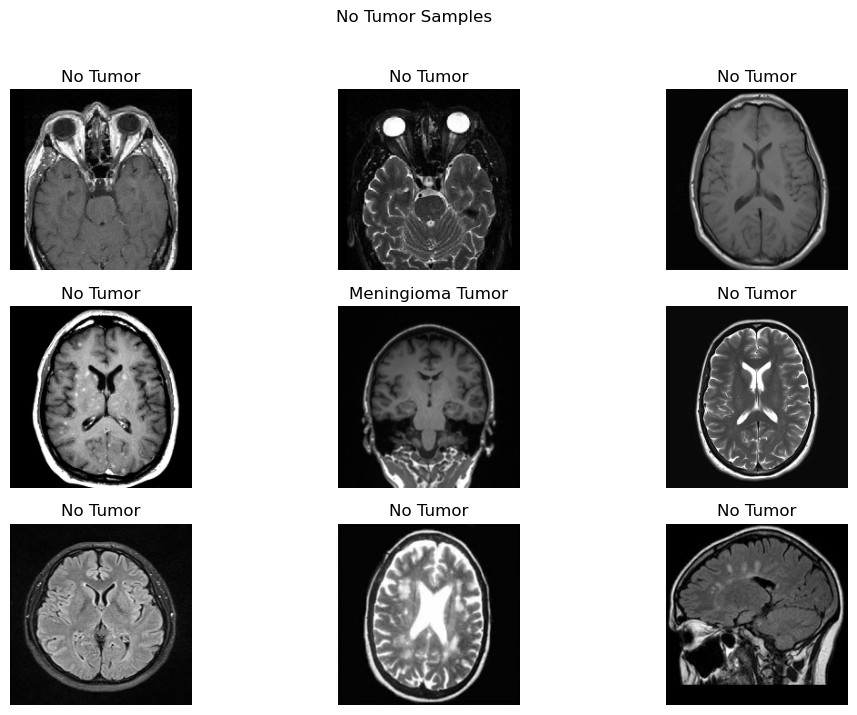

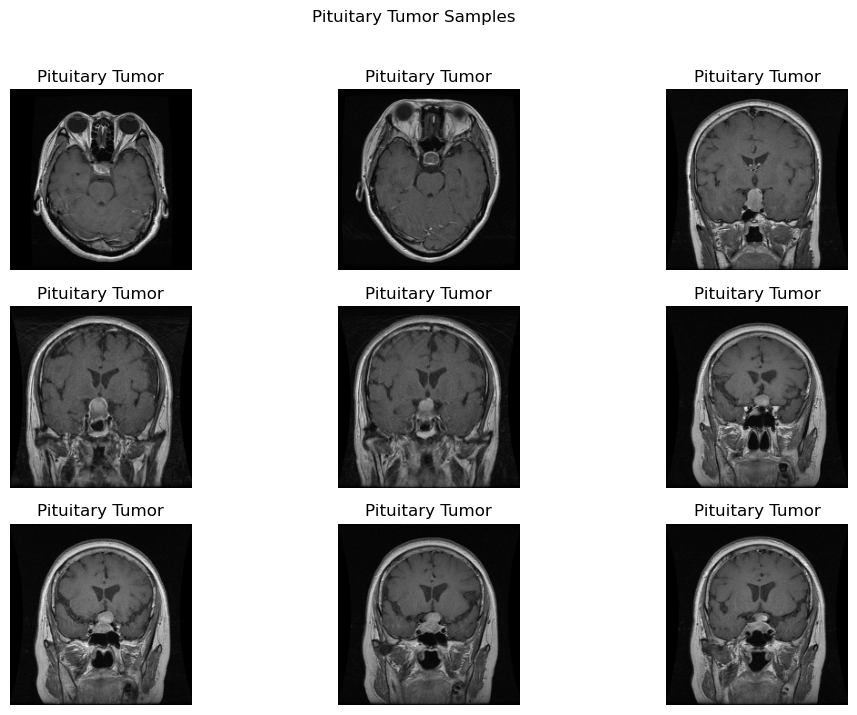

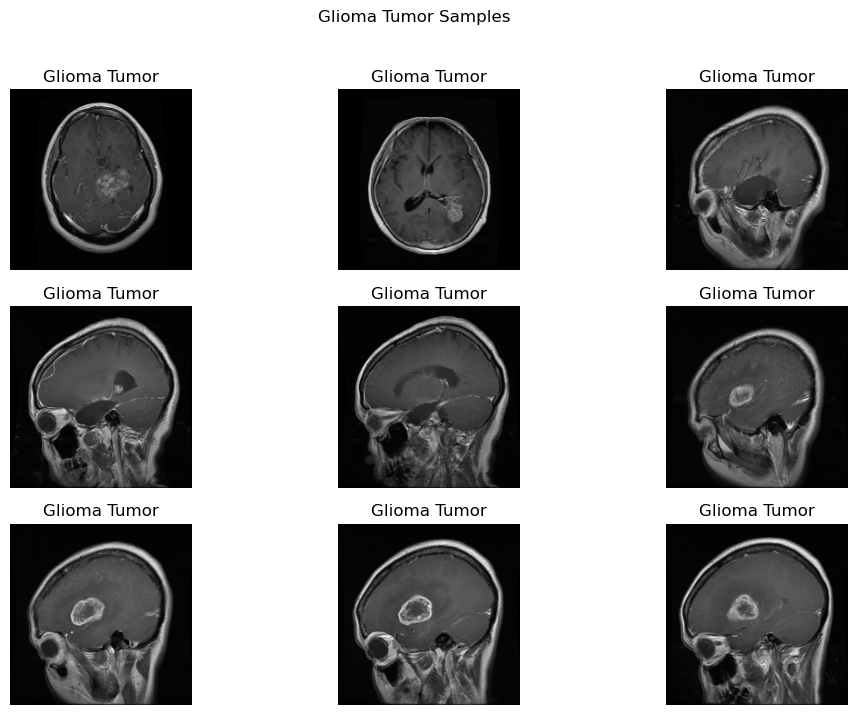

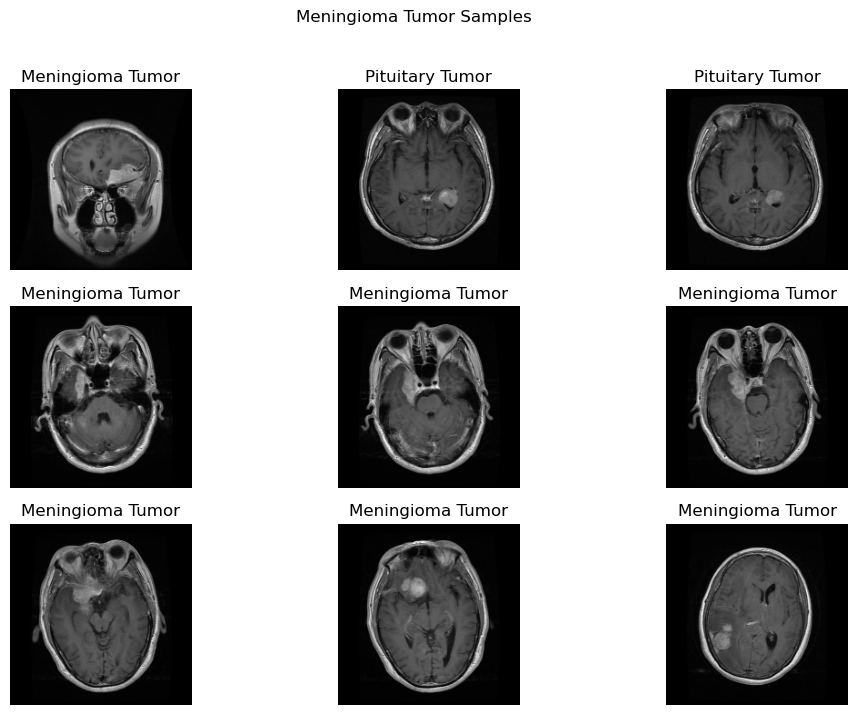

In [5]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}
# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = f"C:\\Users\\Dell\\Documents\\IISC\\Training\\{tumor_folder}\\"
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [6]:
# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m") 
display(styled_table)

Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


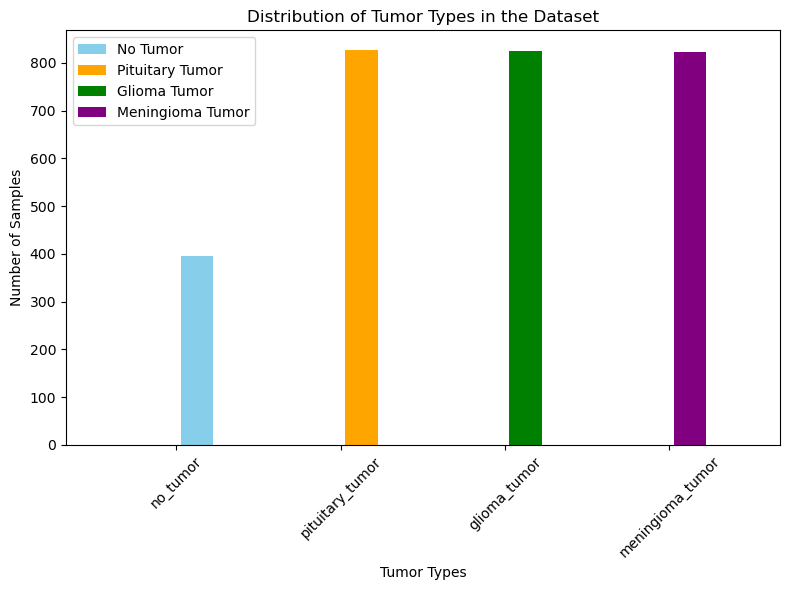

In [7]:
# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show() 

In [8]:
# Cell 8

train_sizes = [0.2, 0.4, 0.6, 0.8]

rbf_acc = []

linear_acc = []

for size in train_sizes:

    # Use only part of the training data

    x_small, _, y_small, _ = train_test_split(
        pca_train,
        ytrain,
        train_size=size,
        stratify=ytrain,
        random_state=42
    )

    # -----------------------------
    # RBF Kernel
    # -----------------------------

    rbf_model = SVC(kernel='rbf')

    rbf_model.fit(x_small, y_small)

    rbf_pred = rbf_model.predict(pca_test)

    rbf_accuracy = accuracy_score(
        ytest,
        rbf_pred
    )

    rbf_acc.append(rbf_accuracy)

    # -----------------------------
    # Linear Kernel
    # -----------------------------

    linear_model = SVC(kernel='linear')

    linear_model.fit(x_small, y_small)

    linear_pred = linear_model.predict(pca_test)

    linear_accuracy = accuracy_score(
        ytest,
        linear_pred
    )

    linear_acc.append(linear_accuracy)

# Print results

print("Training Fractions:", train_sizes)

print("RBF Accuracies:", rbf_acc)

print("Linear Accuracies:", linear_acc)

Training Fractions: [0.2, 0.4, 0.6, 0.8]
RBF Accuracies: [0.7299651567944251, 0.7717770034843205, 0.8153310104529616, 0.8362369337979094]
Linear Accuracies: [0.7073170731707317, 0.7578397212543554, 0.7874564459930313, 0.8101045296167247]


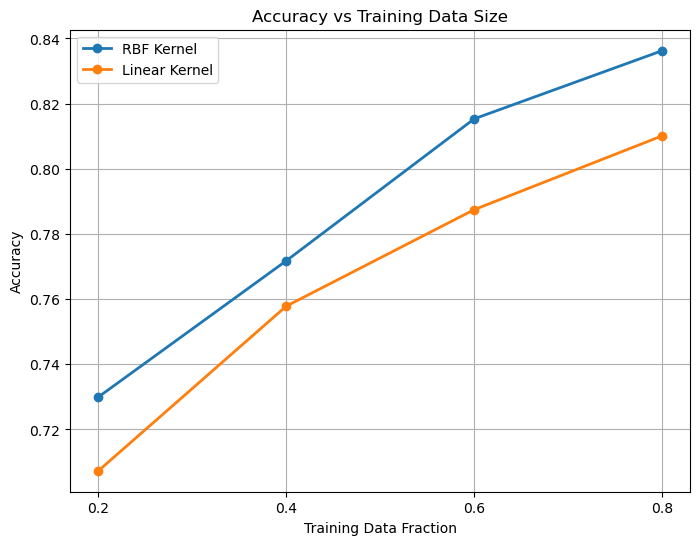

In [9]:
# Cell 9

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    rbf_acc,
    marker='o',
    linewidth=2,
    label='RBF Kernel'
)

plt.plot(
    train_sizes,
    linear_acc,
    marker='o',
    linewidth=2,
    label='Linear Kernel'
)

plt.xlabel("Training Data Fraction")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Training Data Size")

plt.xticks(train_sizes)

plt.legend()

plt.grid(True)

plt.show()